# **A/B Testing**

The goal of this notebook is to determine whether the advertising treatment increases conversion relative to the PSA control and to investigate how conversion varies with ad exposure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportion_confint

np.random.seed(67)
n_iter = 10000
hist_bins = int(np.sqrt(n_iter))

In [2]:
marketing = pd.read_csv('..//data//raw//marketing_AB.csv', index_col = 0)
marketing = marketing.drop(columns = ['user id'])
marketing.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [3]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 23.0+ MB


In [4]:
pd.crosstab(marketing['test group'], marketing['converted'])

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [5]:
conv_rate = marketing.groupby('test group').agg(rate = ('converted', 'mean'))
conv_rate_ad = conv_rate.at['ad', 'rate']
conv_rate_psa = conv_rate.at['psa', 'rate']
print(f"The conversion rate was {100 * conv_rate_ad:.4f}% in the Ad group and {100 * conv_rate_psa:.4f}% in the PSA group")

The conversion rate was 2.5547% in the Ad group and 1.7854% in the PSA group


## **I. Confidence Interval**

We estimate the treatment effect as the difference in conversion rates between the Ad and PSA groups. To quantify the uncertainty around this estimate, we construct a 95% bootstrap confidence interval.

In [6]:
def conf_int(ls, n_iter):

    """
    Input: ls: list of lists of observations to be tested, n_iter: number of bootstrap iterations \\
    Output: 95% confidence interval
    """

    dist = np.empty(n_iter)

    for i in range(n_iter):
        dist[i] = np.mean(np.random.choice(ls[0], len(ls[0]), replace=True)) - np.mean(np.random.choice(ls[1], len(ls[1]), replace=True))
        
    return np.percentile(dist, [2.5, 97.5])

In [7]:
ad_psa = [marketing[marketing['test group'] == 'ad']['converted'], marketing[marketing['test group'] == 'psa']['converted']]
mean_diff = conv_rate_ad - conv_rate_psa
low_ap, high_ap = conf_int(ls = ad_psa, n_iter = n_iter)
print(f'The absolute difference in conversion rates is {mean_diff:.4f} (95% CI [{low_ap:.4f}, {high_ap:.4f}]) with a relative lift of {(conv_rate_ad - conv_rate_psa)/conv_rate_psa:.4f}')

The absolute difference in conversion rates is 0.0077 (95% CI [0.0059, 0.0094]) with a relative lift of 0.4309


The confidence interval excludes zero, providing evidence that the Ad group had a higher conversion rate than the PSA group.

## **II. Hypothesis Testing**

We want to be confident that the improvement due to the treatment is unlikely due to chance. We formalize the hypothesis. 

Let $R$ be the conversion rate. 

\begin{align*}
H_0 &: \ R_{\text{Ad}} = R_{\text{PSA}} \\
H_1 &: \ R_{\text{Ad}} > R_{\text{PSA}}
\end{align*}

The null hypothesis is that the conversion rate between the control group (PSA) and the treatment (Ad) are equal. Under the null hypothesis, any observed difference in conversion rates is attributable to random assignment. The alternative hypothesis is that the Ad treatment produces a higher conversion rate than PSA. We will use two methods to test our hypothesis. First, we do a permutation test.

In [8]:
def mean_diff_dist(ls, n_iter):

    """
    Input: ls: list of lists of observations to be tested, n_iter: number of bootstrap iterations \\
    Output: Null distribution of difference in mean between the two list
    """

    combined = np.concatenate(ls)
    n1 = len(ls[0])

    mean_diffs = np.empty(n_iter)

    for i in range(n_iter):
        shuffled = np.random.permutation(combined)
        mean1 = shuffled[:n1].mean()
        mean2 = shuffled[n1:].mean()
        mean_diffs[i] = mean1 - mean2

    return mean_diffs

In [9]:
dist_prob = mean_diff_dist(ls = ad_psa, n_iter = n_iter)

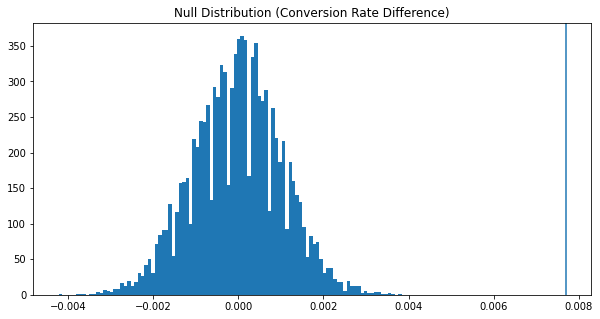

In [10]:
plt.figure(figsize = (10, 5))
plt.hist(dist_prob, bins = hist_bins)
plt.axvline(x = mean_diff)
plt.title('Null Distribution (Conversion Rate Difference)')
plt.savefig('..//outputs//figures//hist.jpg', dpi = 500, bbox_inches = 'tight')
plt.show()

In [11]:
p_value = np.mean(dist_prob >= mean_diff)
print(f"{p_value:.4f}")

0.0000


The permutation test says that none of the 10,000 permutations produced a difference as large as the observed difference, giving an estimated p-value < 0.0001. We can also use a Monte-Carlo correction.

In [12]:
p_value_mc = (np.sum(dist_prob >= mean_diff) + 1) / (n_iter + 1)
print(f"p < {p_value_mc:.4f}")

p < 0.0001


In conclusion, the advertising treatment increased conversion by $0.77$ percentage points, corresponding to a $43.1\%$ relative lift. The $95\%$ confidence interval for the treatment effect was $[0.59, 0.94]$ percentage points, and the difference between conversion rates was statistically significant ($p < 0.0001$).

## **III. Ad Exposure and Conversion**

We have established that the advertising treatment increases conversion relative to the PSA control. The campaign also incurs a cost to the company, so we now examine how conversion varies with ad exposure and whether the observed relationship suggests a potential exposure range worth testing.

In [13]:
total_ads_conv = marketing[(marketing['test group'] == 'ad') & (marketing['converted'] == True)]['total ads']
total_ads_nconv = marketing[(marketing['test group'] == 'ad') & (marketing['converted'] == False)]['total ads']

mean_ads_conv = total_ads_conv.mean()
mean_ads_nconv = total_ads_nconv.mean()
mean_ads_diff = mean_ads_conv - mean_ads_nconv

print('The mean total ads for the converted customers is {:.4f}'.format(mean_ads_conv))
print('The mean total ads for the non-converted customers is {:.4f}'.format(mean_ads_nconv))
print(f'The difference between mean total ads is {mean_ads_diff:.4f}')

The mean total ads for the converted customers is 83.9056
The mean total ads for the non-converted customers is 23.2744
The difference between mean total ads is 60.6311


Among users in the Ad group, converted users saw significantly more ads on average than non-converted users. The relationship must not be taken as causal because ad exposure was not randomized. Users who are more engaged may both receive more ad exposures and be more likely to convert. Verifying whether additional exposure itself increases conversion needs a separate test.

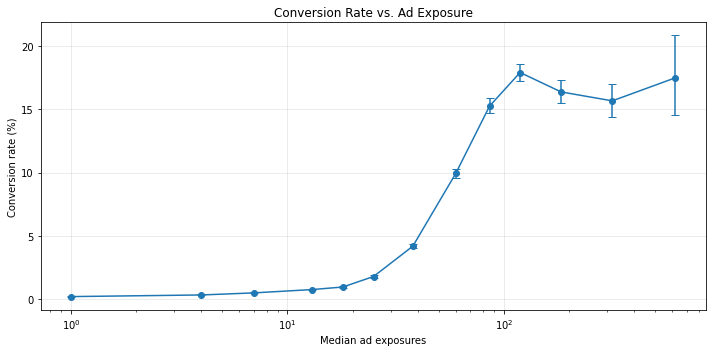

In [14]:
market_ad = marketing[marketing['test group'] == 'ad']
conv_df = market_ad[['total ads', 'converted']].dropna().copy()

bins = [0, 2, 5, 10, 15, 20, 30, 50, 75, 100, 150, 250, 500, np.inf]
labels = ['1–2', '3–5', '6–10', '11–15', '16–20', '21–30', '31–50', '51–75', '76–100', '101–150', '151–250', '251–500', '501+']

conv_df['ads_bin'] = pd.cut(conv_df['total ads'], bins=bins, labels=labels, include_lowest=True)

conversion_by_bin = conv_df.groupby('ads_bin', observed=True).agg(n=('converted', 'size'), conversions=('converted', 'sum'), conversion_rate=('converted', 'mean'), median_ads=('total ads', 'median')).reset_index()

ci = proportion_confint(conversion_by_bin['conversions'], conversion_by_bin['n'], alpha=0.05, method='wilson')
conversion_by_bin['ci_low'] = ci[0]
conversion_by_bin['ci_high'] = ci[1]

plt.figure(figsize=(10, 5))
plt.errorbar(conversion_by_bin['median_ads'], 100 * conversion_by_bin['conversion_rate'], yerr=[100 * (conversion_by_bin['conversion_rate'] - conversion_by_bin['ci_low']), 100 * (conversion_by_bin['ci_high'] - conversion_by_bin['conversion_rate'])], fmt='o-', capsize=4)
plt.xlabel('Median ad exposures')
plt.ylabel('Conversion rate (%)')
plt.xscale('log')
plt.title('Conversion Rate vs. Ad Exposure')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('..//outputs//figures//conv_ad.jpg', dpi = 500, bbox_inches = 'tight')
plt.savefig('..//outputs//figures//conv_ad.png', dpi = 500, bbox_inches = 'tight')
plt.show()

In [15]:
conversion_by_bin[['ads_bin', 'n', 'conversions', 'conversion_rate', 'median_ads']]

,ads_bin,n,conversions,conversion_rate,median_ads
0,1–2,92209,177,0.001920,1.0
1,3–5,77753,250,0.003215,4.0
2,6–10,79537,386,0.004853,7.0
3,11–15,66564,498,0.007482,13.0
4,16–20,56770,538,0.009477,18.0
5,21–30,66150,1177,0.017793,25.0
6,31–50,59391,2483,0.041808,38.0
7,51–75,30078,2988,0.099342,60.0
8,76–100,14071,2147,0.152583,86.0
9,101–150,11854,2123,0.179096,119.0


The conversion rate increases rapidly with ad exposure and appears to level off around 100+ exposures. However, the highest-exposure groups contain substantially fewer users, so the apparent plateau should be interpreted cautiously. Again, the relationship must not be taken as causal for two reasons: first, ad exposures may gauge engagement. Higher ads are seen by users actively engaging with the product. It is likely that active engagement is a predictor for conversion. Second, higher ads are seen by users who already converted. Being converted increases the likelihood of the user to actively engage with the product. Verifying the nature of the relationship requires further test.

## **IV. Business Recommendation**

The advertising treatment increased conversion relative to the PSA control by **0.77 percentage points**, corresponding to a **43.1% relative lift**. The 95% confidence interval for the treatment effect was approximately [0.59, 0.94] percentage points, and **the difference was statistically significant**. This provides evidence that showing the advertisement increases conversion. 

However, the dataset does not contain advertising costs, revenue, or profit, so the financial efficiency of the campaign cannot be established directly. Ad exposure was not randomized, so the observed relationship between exposure and conversion should be interpreted as descriptive rather than causal. Conversion rates increased rapidly with exposure and appeared to level off around 100+ exposures, but the high-exposure groups contain relatively few observations. 

The ad treatment should therefore be kept as the default treatment based on its positive conversion effect, but subject to a separate profitability analysis. A follow-up experiment varying exposure frequency would be required to determine whether increasing exposure itself causes higher conversion and to identify an optimal exposure level.